[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_4/04C-GradientBoosting.ipynb)

# 04C — Gradient Boosting

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 4, Notebook C — Hour 3**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`04B` built an ensemble by growing many strong trees **independently** and averaging them. Each
tree was deep, flexible and noisy; averaging removed much of the noise. That attacks **variance**,
and it cannot touch bias: if every tree is wrong in the same way, so is their average.

This notebook builds an ensemble the other way round. It grows **weak** trees — two or three
questions deep — **one after another**, and each new tree is fitted to whatever the ensemble so far
still gets wrong. That attacks **bias**, a little at a time. The method is **gradient boosting**, and
on tables of measurements it is, with the random forest, the strongest tool in this course.

It also has a dial that the forest did not: stop too late and it overfits. `04B` §5 promised that the
number of rounds would behave like `04A`'s depth, and section 3 keeps the promise.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain boosting as building a model **one tree at a time**, each tree fitted to what the model so
  far gets wrong;
- say why each step is the **negative gradient** of the loss, which is where the name comes from;
- explain why the trees are shallow and why each one's contribution is shrunk by a **learning
  rate**;
- recognise the number of rounds as a **flexibility dial that overfits**, and choose it by **early
  stopping**;
- contrast bagging and boosting: independent against sequential, deep against shallow, variance
  against bias;
- compare `HistGradientBoostingRegressor` fairly with a random forest, and know that the winner
  depends on the table;
- read a **partial dependence** plot and **ICE** curves, and say what each can and cannot show;
- say, with the evidence, when boosted trees beat deep learning on tabular data, and where that
  stops being true.

## Where this sits in the pipeline

The same map as `04A` and `04B`. Boosting changes the same two boxes the forest did — the model
family and the way it is fitted — and it adds a validation step *inside* the fit, which is new.

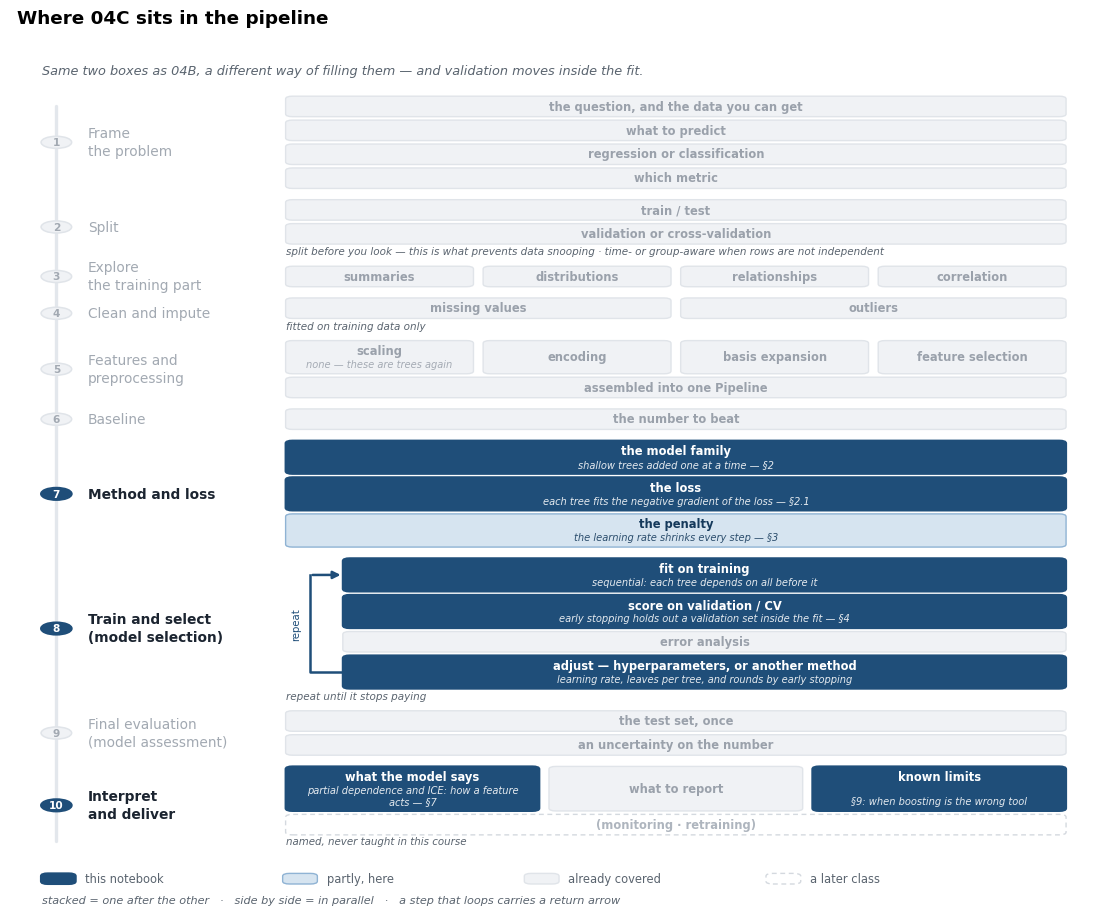

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "done", "5.after": "done",
     "6": "done", "7.1": "now", "7.2": "now", "7.3": "part",
     "8.1": "now", "8.2": "now", "8.3": "done", "8.4": "now",
     "9": "done", "10.1": "now", "10.2": "done", "10.3": "now"},
    notes={"5.1": "none — these are trees again",
           "7.1": "shallow trees added one at a time — §2",
           "7.2": "each tree fits the negative gradient of the loss — §2.1",
           "7.3": "the learning rate shrinks every step — §3",
           "8.1": "sequential: each tree depends on all before it",
           "8.2": "early stopping holds out a validation set inside the fit — §4",
           "8.4": "learning rate, leaves per tree, and rounds by early stopping",
           "10.1": "partial dependence and ICE: how a feature acts — §7",
           "10.3": "§9: when boosting is the wrong tool"},
    title="Where 04C sits in the pipeline",
    lead="Same two boxes as 04B, a different way of filling them — and validation moves inside the fit.")
plt.show()

**The step worth remembering is 8.4.** A forest's size was set by patience. A boosted model's size
is set by the data, because too many rounds make it worse — so the fit itself has to watch a
validation set and stop.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (GradientBoostingRegressor, HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

# 1. The other way round

A forest and a boosted model are both sums of trees, and they are built on opposite principles.

| | Random forest (`04B`) | Gradient boosting (this notebook) |
|---|---|---|
| the trees are | deep — low bias, high variance | shallow — high bias, low variance |
| they are built | independently, each on its own resample | in sequence, each on what the rest got wrong |
| they are combined by | averaging | adding |
| what the ensemble reduces | variance | bias |
| more trees | never hurts (`04B` §5) | eventually overfits (section 3) |

A **shallow** tree — two or three questions — is a crude model. It can say "large values of this
feature, higher target" and not much more. On its own it underfits badly. The idea of boosting is
that many crude corrections, each aimed at what is still wrong, add up to something accurate. The
next section does it by hand.

# 2. Boosting by hand: each tree fits what is left

The recipe, for a regression target and squared error:

1. Start with the simplest prediction there is: the mean of $y$, for everyone.
2. Compute the **residuals** — $y_i$ minus the current prediction. They are what the model still
   gets wrong.
3. Fit a small tree to the residuals, not to $y$. The tree learns where the model is too low and
   where it is too high.
4. Add that tree's prediction to the model, multiplied by a small number $\nu$, the **learning
   rate**.
5. Go back to step 2.

After $M$ rounds the model is

$$
\hat{f}(x) \;=\; \bar{y} \;+\; \nu\,t_1(x) \;+\; \nu\,t_2(x) \;+\; \cdots \;+\; \nu\,t_M(x),
$$

a sum of $M$ small trees, each fitted to the residuals of all the ones before it.

The data are sixty noisy measurements of a smooth curve — the same kind of experiment as `02C` and
`03B`. The trees have depth 2, so each can split the axis into at most four intervals.

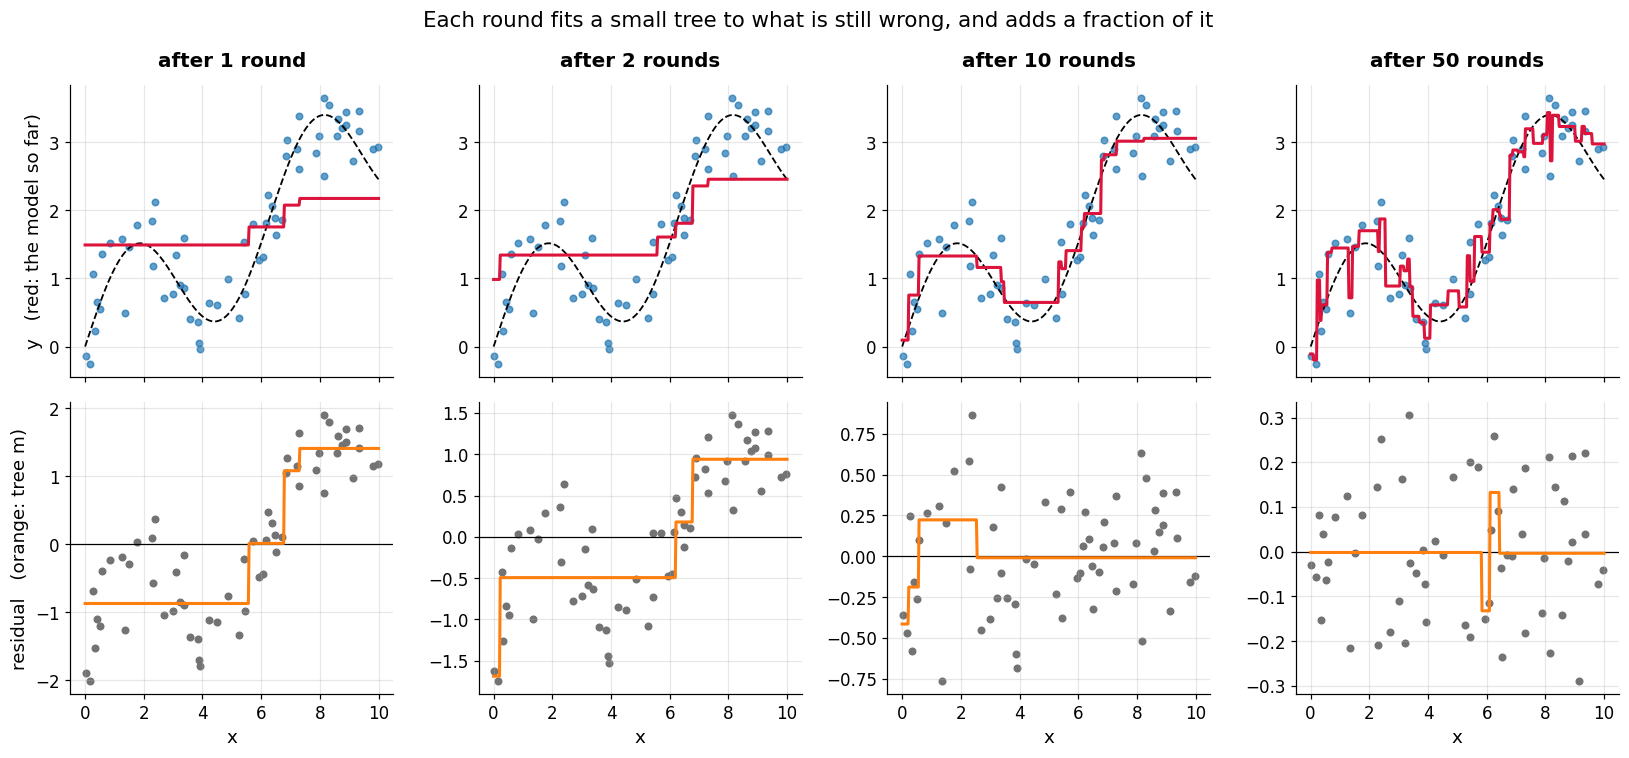

largest difference between the loop and GradientBoostingRegressor: 8.9e-16


In [ ]:
def true_curve(t):
    """The relationship the measurements come from."""
    return np.sin(t) + 0.3 * t

demo_rng = np.random.default_rng(0)
n_points = 60
x = np.sort(demo_rng.uniform(0, 10, n_points))
X_demo = x.reshape(-1, 1)
y_demo = true_curve(x) + demo_rng.normal(0, 0.4, n_points)

# The boosting loop, written out. criterion="friedman_mse" is a small variant of squared error that
# scikit-learn's boosting uses by default; it is set here only so the check below can match exactly.
learning_rate, depth, rounds = 0.3, 2, 50
grid = np.linspace(0, 10, 400).reshape(-1, 1)

prediction = np.full(n_points, y_demo.mean())        # step 1: the mean, for everyone
on_grid = np.full(len(grid), y_demo.mean())
history = {0: (prediction.copy(), on_grid.copy(), None, None)}
for m in range(1, rounds + 1):
    residual = y_demo - prediction                     # step 2: what is still wrong
    tree = DecisionTreeRegressor(max_depth=depth, criterion="friedman_mse",
                                 random_state=0).fit(X_demo, residual)   # step 3
    prediction = prediction + learning_rate * tree.predict(X_demo)       # step 4
    on_grid = on_grid + learning_rate * tree.predict(grid)
    history[m] = (prediction.copy(), on_grid.copy(), residual, tree.predict(grid))

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True)
for column, m in enumerate([1, 2, 10, 50]):
    _, fit_on_grid, residual, tree_on_grid = history[m]
    top, bottom = axes[0, column], axes[1, column]
    top.scatter(x, y_demo, s=18, color="tab:blue", alpha=0.7)
    top.plot(grid, true_curve(grid), "k--", linewidth=1.2)
    top.plot(grid, fit_on_grid, color="crimson", linewidth=2)
    top.set_title(f"after {m} round{'s' if m > 1 else ''}")
    bottom.axhline(0, color="black", linewidth=0.8)
    bottom.scatter(x, residual, s=18, color="0.45")
    bottom.plot(grid, tree_on_grid, color="tab:orange", linewidth=2)
    bottom.set_xlabel("x")
axes[0, 0].set_ylabel("y   (red: the model so far)")
axes[1, 0].set_ylabel("residual   (orange: tree m)")
fig.suptitle("Each round fits a small tree to what is still wrong, and adds a fraction of it",
             fontsize=14)
plt.show()

# The same model from scikit-learn, for comparison.
library = GradientBoostingRegressor(n_estimators=rounds, learning_rate=learning_rate,
                                    max_depth=depth, random_state=0).fit(X_demo, y_demo)
print(f"largest difference between the loop and GradientBoostingRegressor: "
      f"{np.abs(prediction - library.predict(X_demo)).max():.1e}")

Read the figure by columns. The top row is the model after $m$ rounds (red) against the data and
the true curve (dashed). The bottom row is what round $m$ was given to work on — the residuals
before it — and the depth-2 tree fitted to them (orange).

- **After 1 round** the model is the mean plus a crude step: one tree, four intervals, and only 30%
  of its height, because of the learning rate.
- **After 2 rounds** the second tree has been fitted to what the first left behind, and its steps
  sit in different places.
- **After 10 rounds** the steps have accumulated into a staircase that follows the curve.
- **After 50 rounds** the model follows the data closely — too closely. The red curve has started to
  spike towards individual points, near $x \approx 0.3$ and $x \approx 5.5$, and the residuals below
  are small and patternless: noise, which the latest tree is chasing.

That last observation is the problem section 3 measures; for this learning rate it will find that
the best number of rounds is 13, so 50 is already too many. Meanwhile the printed line checks the
claim that this loop *is* gradient boosting: `scikit-learn`'s `GradientBoostingRegressor`, given the
same learning rate, depth and number of rounds, makes the same predictions to within rounding error.

## 2.1 Why it is called *gradient* boosting

Nothing above mentioned a gradient. It was there all the same.

For squared error, the loss for one sample is $L = \tfrac12\,(y - F)^2$, where $F$ is the model's
current prediction. Its derivative with respect to that prediction is

$$
\frac{\partial L}{\partial F} \;=\; -(y - F),
$$

so the residual $y - F$ is exactly the **negative gradient** of the loss. Fitting a tree to the
residuals, and adding a small multiple of it, is a step of gradient descent — taken not on a few
parameters but on the model's predictions themselves, with a tree to say what the step should look
like everywhere else (Friedman, 2001).

That view is what makes the method general. Change the loss and the only thing that changes is what
the trees are fitted to: its negative gradient. For classification with the cross-entropy of `02B`
§5, where the model outputs log-odds and $\hat p$ is the predicted probability, the negative
gradient works out to

$$
-\frac{\partial L}{\partial F} \;=\; y - \hat{p},
$$

the label minus the predicted probability. Each tree is fitted to how far the probabilities still
are from the answers. That is the central change in `HistGradientBoostingClassifier`. There are
smaller ones — it starts from the log-odds rather than the mean, sets each leaf's value with a
second-order step that also uses $\hat p(1-\hat p)$, and with more than two classes grows one tree
per class every round — but the idea is the same.

# 3. The dial that overfits

`04B` §5 showed that a forest cannot overfit by having too many trees: each tree is independent, and
more of them only estimate the same average more precisely. Boosting is different in kind. Every
round is fitted to the residuals of the rounds before, so every round makes the model **more
flexible**. After enough of them, the residuals left are noise, and the next tree fits the noise.

Two settings interact. The **learning rate** $\nu$ is how much of each tree is kept; the **number of
rounds** $M$ is how many trees there are. A small $\nu$ takes small steps, so it needs more of them
to get anywhere.

The next cell boosts the same sixty points for up to 2000 rounds at three learning rates, and after
every round measures the error on the training points and on 2000 fresh measurements from the same
curve — a luxury only simulated data allow; section 4 does without it.

1. How does the **training** error behave as the rounds increase?
2. Will the error on fresh data keep falling, level off, or turn back up?
3. Will the smallest learning rate need more rounds to reach its best, or fewer?

**Think about your answer before running this cell.**

In [ ]:
fresh_x = demo_rng.uniform(0, 10, 2000).reshape(-1, 1)
fresh_y = true_curve(fresh_x.ravel()) + demo_rng.normal(0, 0.4, 2000)

curves = {}
for rate in [1.0, 0.3, 0.1]:
    model = GradientBoostingRegressor(n_estimators=2000, learning_rate=rate, max_depth=2,
                                      random_state=0).fit(X_demo, y_demo)
    # staged_predict gives the prediction after every round, without refitting
    training = [np.mean((y_demo - p) ** 2) for p in model.staged_predict(X_demo)]
    fresh = [np.mean((fresh_y - p) ** 2) for p in model.staged_predict(fresh_x)]
    curves[rate] = (training, fresh)

print(f"{'learning rate':>14}{'best round':>12}{'error there':>13}{'error at 2000':>15}"
      f"{'training at 2000':>18}")
for rate, (training, fresh) in curves.items():
    best = int(np.argmin(fresh))
    print(f"{rate:>14}{best + 1:>12}{fresh[best]:>13.3f}{fresh[-1]:>15.3f}{training[-1]:>18.4f}")

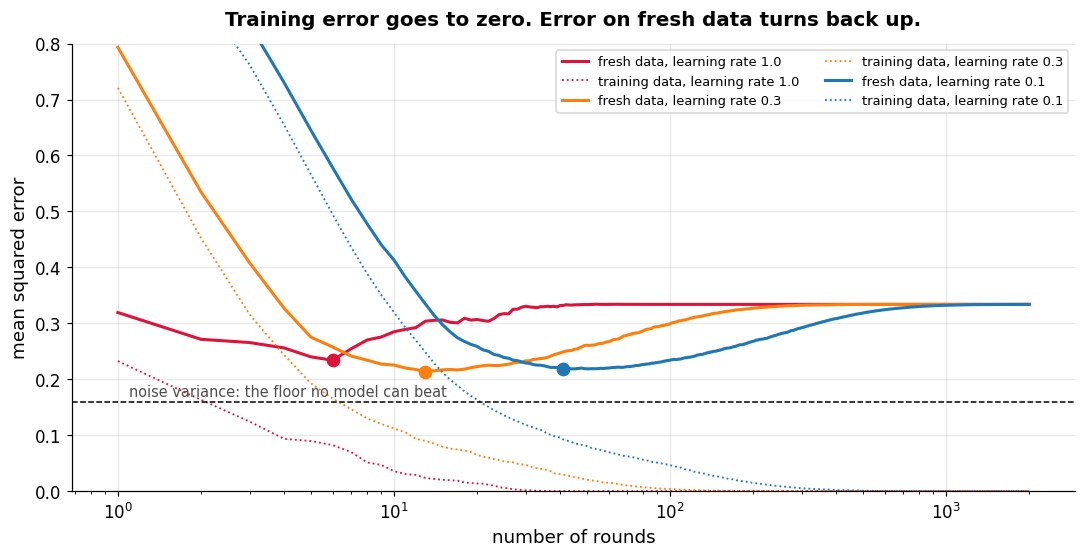

 learning rate  best round  error there  error at 2000  training at 2000
           1.0           6        0.234          0.334            0.0000
           0.3          13        0.213          0.334            0.0000
           0.1          41        0.218          0.334            0.0000


In [ ]:
fig, axis = plt.subplots(figsize=(10, 5.2))
colours = {1.0: "crimson", 0.3: "tab:orange", 0.1: "tab:blue"}
rounds_axis = np.arange(1, 2001)
for rate, (training, fresh) in curves.items():
    axis.plot(rounds_axis, fresh, color=colours[rate], linewidth=2,
              label=f"fresh data, learning rate {rate}")
    axis.plot(rounds_axis, training, color=colours[rate], linewidth=1.2, linestyle=":",
              label=f"training data, learning rate {rate}")
    best = int(np.argmin(fresh))
    axis.plot(best + 1, fresh[best], "o", color=colours[rate], markersize=8)
axis.axhline(0.4 ** 2, color="black", linestyle="--", linewidth=1)
axis.text(1.1, 0.4 ** 2 * 1.06, "noise variance: the floor no model can beat", fontsize=9.5,
          color="0.3")
axis.set_xscale("log")
axis.set_ylim(0, 0.8)
axis.set_xlabel("number of rounds")
axis.set_ylabel("mean squared error")
axis.set_title("Training error goes to zero. Error on fresh data turns back up.")
axis.legend(fontsize=8.5, ncol=2, loc="upper right")
plt.show()

print(f"{'learning rate':>14}{'best round':>12}{'error there':>13}{'error at 2000':>15}"
      f"{'training at 2000':>18}")
for rate, (training, fresh) in curves.items():
    best = int(np.argmin(fresh))
    print(f"{rate:>14}{best + 1:>12}{fresh[best]:>13.3f}{fresh[-1]:>15.3f}{training[-1]:>18.4f}")

Three things to read off the figure and the table.

**Training error goes to zero.** By 2000 rounds every learning rate has driven it to 0.0000, to four
decimals: the sum of trees passes through every one of the sixty points, noise included. That is
`02C`'s memorising model, arrived at one small step at a time.

**Error on fresh data has a minimum and then rises.** Each curve falls, bottoms out — at round
6, 13 and 41 for learning rates 1.0, 0.3 and 0.1 — and then climbs to 0.334, far above the
best it reached. The dashed line is the noise variance, $0.4^2 = 0.16$: the error of the true curve
itself. The best models come within 0.05 to 0.07 of it; the overfitted ones do not come close.

**A smaller learning rate needs many more rounds**, and reaches a minimum about as good. Dividing
$\nu$ by ten multiplied the best number of rounds by about seven, from 6 to 41; here the three
minima, 0.213 to 0.234, are within 10% of each other. The recommendation in *The Elements of
Statistical Learning* (Hastie, Tibshirani & Friedman, ch. 10.12.1) is a small learning rate — below
0.1 — with the number of rounds chosen by early stopping: small steps generalise at least as well as
large ones, and usually a little better. Their real cost is time.

**How fast the error rises depends on the setting.** Sixty noisy points and a learning rate as large
as 1.0 are close to the worst case. With a small learning rate and plenty of data the rise past the
minimum is slow — ISLR (James et al., ch. 8.2.3) notes that boosting's overfitting in the number of
rounds "tends to occur slowly if at all" — which is why early stopping, next section, is cheap
insurance rather than a delicate operation.

> In a forest, the number of trees is set by patience. In boosting it is a **flexibility dial**,
> like `04A`'s depth: it has a best value, and both sides of it are worse.

# 4. Early stopping

Section 3 found the best number of rounds by looking at fresh data. A real study has no fresh data
to spare — and the test set is not allowed to choose anything (`02C` §5). So the fit itself sets a
small part of the training data aside as a **validation set**, watches the error on it after every
round, and stops when it has not improved for a while. That is **early stopping**, and it is how the
number of rounds is chosen in practice.

`GradientBoostingRegressor` needs two arguments for it: `validation_fraction`, the share of the
training data set aside, and `n_iter_no_change`, how many rounds without improvement to wait before
stopping. The cell below gives it 2000 rounds to work with, at learning rate 0.3, and lets it
decide.

In [ ]:
stopping = GradientBoostingRegressor(n_estimators=2000, learning_rate=0.3, max_depth=2,
                                     validation_fraction=0.2, n_iter_no_change=10,
                                     random_state=0).fit(X_demo, y_demo)
_, fresh = curves[0.3]
print(f"rounds allowed:                         2000")
print(f"rounds early stopping kept:             {stopping.n_estimators_}")
print(f"best round on 2000 fresh points (§3):   {int(np.argmin(fresh)) + 1}")
print(f"\nerror on the fresh points — early-stopped model: "
      f"{np.mean((fresh_y - stopping.predict(fresh_x)) ** 2):.3f}")
print(f"                           — all 2000 rounds:     {fresh[-1]:.3f}")
print(f"                           — the best possible:   {min(fresh):.3f}")

rounds allowed:                         2000
rounds early stopping kept:             14
best round on 2000 fresh points (§3):   13

error on the fresh points — early-stopped model: 0.255
                           — all 2000 rounds:     0.334
                           — the best possible:   0.213


The fit stopped at round 14. That number needs reading with care: `scikit-learn` stops only once a
round does worse on the held-out points than every one of the `n_iter_no_change` rounds before it —
ten here — and it **keeps** every round up to that point, including the ones it waited through. By
its own twelve held-out points the best model had fewer rounds than that; the one it returns has 14.
That 14 happens to sit close to the true best, 13, found with two thousand fresh points; with twelve
points to judge by, an estimate this rough is the most one can expect.

Its error on fresh data is 0.255, not the best possible 0.213, and part of the reason is the price
of the method: to hold twelve points out, it fitted its trees to the other 48, and a model fitted to
less data is a worse model. It is still far better than running all 2000 rounds, which reach 0.334.

Two consequences of how it works are worth knowing.

- **The validation set comes out of the training data.** With sixty points, twelve fewer to train on
  is a real cost, as the error above shows; with twenty thousand it is negligible. That is why
  `HistGradientBoostingRegressor`, next section, switches early stopping on **by itself** above
  10,000 samples.
- **It is a model-selection step, done inside the fit.** It chooses a hyperparameter on held-out
  data, exactly as `02C` §4's cross-validation does, only faster. The test set still stays untouched
  until the end.

**One more setting is worth knowing by name: subsampling.** Friedman's *stochastic* gradient
boosting (Friedman, 2002) fits each tree to a random half or so of the rows rather than to all of
them — `subsample=0.5` in `GradientBoostingRegressor`. It usually improves accuracy a little, for
the same reason `04B`'s random subsets helped a forest: the trees become less alike. And it brings
back something `04B` §6 attributed only to bagging: the rows a tree did not see give an **out-of-
bag** estimate of how much that round improved the model, stored in `oob_improvement_`.
`HistGradientBoostingRegressor` does not subsample rows, so it has no out-of-bag estimate, and early
stopping's validation set is its substitute.

# 5. Boosting against a forest

The sixty points were for seeing the mechanism. The method earns its reputation on large tables, and
this section asks the question every user of both methods asks: **is boosting better than the forest
of `04B`?**

The table used here is the **California housing** data (Pace & Barry, 1997): 20,640 districts from
the 1990 United States census, eight features each — median income, the houses' age, average numbers
of rooms and bedrooms, population, average occupancy, latitude and longitude — and the target is the
median house value, in units of \$100,000. It is not a physics dataset. It is here because it is the
standard example on which the difference between the two methods is clearly visible, and it is part
of the tabular benchmark section 8 discusses. Section 7 turns to a scientific table, where the
answer turns out to be different.

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)       # downloads once, then reuses the copy
X_ca, y_ca = housing.data, housing.target
print(f"{X_ca.shape[0]} districts, {X_ca.shape[1]} features: {', '.join(X_ca.columns)}")
print(f"median house value: median {y_ca.median():.2f}, in units of $100,000")

X_ca_train, X_ca_test, y_ca_train, y_ca_test = train_test_split(X_ca, y_ca, test_size=0.25,
                                                                random_state=0)
print(f"{len(y_ca_train)} for training and comparing; the rest is not used in this section")

20640 districts, 8 features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
median house value: median 1.80, in units of $100,000
15480 for training and comparing; the rest is not used in this section


**`HistGradientBoostingRegressor`** is the implementation to use on data this size. It is gradient
boosting exactly as in section 2, with two engineering changes of the kind LightGBM made popular (Ke
et al., 2017). Before fitting, every feature is sorted into at most 255 **bins**, and trees split
only on bin boundaries — searching 255 candidate thresholds instead of thousands makes each tree far
cheaper and costs almost nothing in accuracy. And each tree is grown **leaf by leaf**, always
splitting the leaf where the loss falls most, up to a maximum number of leaves rather than a fixed
depth.

Its defaults are sensible: learning rate 0.1, trees of up to 31 leaves, and at most 100 rounds
(`max_iter`), with early stopping switched on automatically because the data exceed 10,000 samples.

The comparison below is five-fold cross-validation on the training part, and every model is timed.
The contenders are the mean, a linear model (ridge, as in `03C`), a random forest of 300 trees
drawing a third of the features at each split — the usual regression default, `04B` §4 — and three
boosted models: the defaults; the defaults allowed up to 3000 rounds; and a smaller learning rate
with larger trees.

In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=0)
contenders = [
    ("predict the mean", None),
    ("ridge (03C)", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("random forest, 300 trees", RandomForestRegressor(n_estimators=300, max_features=1 / 3,
                                                        n_jobs=-1, random_state=0)),
    ("boosting, defaults", HistGradientBoostingRegressor(random_state=0)),
    ("boosting, up to 3000 rounds", HistGradientBoostingRegressor(max_iter=3000,
                                                                   random_state=0)),
    ("... and rate 0.05, 63 leaves", HistGradientBoostingRegressor(max_iter=3000,
                                                                    learning_rate=0.05,
                                                                    max_leaf_nodes=63,
                                                                    random_state=0)),
]

print(f"{'':32}{'RMSE':>8}{'fold spread':>13}{'seconds':>9}{'rounds used':>13}")
for name, model in contenders:
    if model is None:
        print(f"{name:32}{y_ca_train.std(ddof=0):>8.3f}")
        continue
    start = time.time()
    scores = -cross_val_score(model, X_ca_train, y_ca_train, cv=folds,
                              scoring="neg_root_mean_squared_error")
    seconds = time.time() - start
    used = ""
    if isinstance(model, HistGradientBoostingRegressor):
        used = model.fit(X_ca_train, y_ca_train).n_iter_
    print(f"{name:32}{scores.mean():>8.3f}{scores.std():>13.3f}{seconds:>9.1f}{str(used):>13}")

                                    RMSE  fold spread  seconds  rounds used
predict the mean                   1.155
ridge (03C)                        0.725        0.014      0.0             


random forest, 300 trees           0.499        0.012      5.0             


boosting, defaults                 0.471        0.016      2.0          100


boosting, up to 3000 rounds        0.463        0.015      3.1          264


... and rate 0.05, 63 leaves       0.460        0.015      9.9          267


Four readings, in order of importance.

**Both tree ensembles are far ahead of the linear model.** Ridge's error, 0.725, is about half as
large again as the trees'. House prices depend on location and income in ways that are nothing like
a weighted sum of the features, and a method that carves the feature space into regions does much
better.

**Boosting beats the forest, clearly.** The best boosted model's error, 0.460, is 0.039 below the
forest's 0.499 — about two and a half fold spreads, so this is not noise. Even the untouched
defaults, at 0.471, win. On this table, the reputation is earned.

**The defaults stopped at their cap.** The default model used 100 rounds: all 100 it was allowed, so
early stopping never triggered and the model was still improving when it was cut off. Given room, it
stopped by itself after 264 rounds and improved to 0.463. It won anyway here, but a model cut off
early is not the model you think you are comparing. **Before comparing boosting with anything, check
that it was not stopped by the `max_iter` cap.**

**And it was fast.** Compare the seconds column: the uncapped boosted model cross-validated in less
time than the forest, because its trees are cheap to grow — they search at most 255 bins rather than
every value. The tuned one, with a smaller learning rate and bigger trees, took about twice the
forest's time. The times depend on your machine; the proportions are what matter.

## 5.1 Missing values and categories

Two practical properties make `HistGradientBoostingRegressor` a good default for real tables.

**It accepts missing values.** When a feature is missing, the trees learn, at every split, which
side the missing values should go to — so missingness is handled by the fit rather than by an
imputation step decided in advance, and if being missing is itself informative the model can use it.
The cell below blanks a fifth of every feature at random and cross-validates again. A linear model
cannot be fitted to that table at all without imputing first (`01C` §5.6). Recent versions of
`scikit-learn`'s single trees and forests accept missing values too; the linear models do not.

**It accepts categories.** A column stored with pandas' `category` type is split on groups of
categories directly, with no one-hot encoding (`01C` §2.5.1) — that is what the default
`categorical_features="from_dtype"` means. The housing features are all numerical, so there is
nothing to show here; exercise 3 gives you a column to try it on.

In [ ]:
blanking = np.random.default_rng(1)
X_holes = X_ca_train.mask(blanking.random(X_ca_train.shape) < 0.2)   # a fifth of every column, gone
print(f"missing entries: {X_holes.isna().to_numpy().mean():.1%} of the table")

scores = -cross_val_score(HistGradientBoostingRegressor(max_iter=3000, random_state=0), X_holes,
                          y_ca_train, cv=folds, scoring="neg_root_mean_squared_error")
print(f"boosting on the table with holes:  RMSE {scores.mean():.3f}")

try:
    Ridge().fit(X_holes, y_ca_train)
except ValueError as problem:
    print(f"\nridge on the same table: {str(problem).splitlines()[0]}")

missing entries: 19.9% of the table


boosting on the table with holes:  RMSE 0.592

ridge on the same table: Input X contains NaN.


With a fifth of every measurement missing, the boosted model's error rose from 0.463 to 0.592 —
worse, as it must be with less information, but it fitted without complaint and without an
imputation step. Ridge refused.

# 6. XGBoost, LightGBM and CatBoost

Gradient boosting on tables is dominated by three open-source libraries, and you will meet their
names in every applied paper. They implement the same idea as section 2, with different engineering.

- **XGBoost** (Chen & Guestrin, 2016) made boosting fast and robust at scale. It adds an explicit
  penalty on the number of leaves and the size of their outputs to the loss — the `03C` idea,
  applied to trees — and uses second derivatives of the loss as well as first when choosing splits.
- **LightGBM** (Ke et al., 2017) popularised the histogram binning of section 5 and grows each tree
  leaf by leaf, always splitting where the loss falls most. `HistGradientBoostingRegressor` is
  `scikit-learn`'s implementation, inspired by LightGBM.
- **CatBoost** (Prokhorenkova et al., 2018) specialises in categorical features.

All three have a `scikit-learn`-compatible interface — `fit`, `predict`, and they drop into a
pipeline or a `GridSearchCV` like anything else in this course — so moving to one of them changes
the import line, not the analysis. On most tables their accuracy is similar to each other's and to
`HistGradientBoostingRegressor`'s; the differences are in speed, memory, and the details of missing-
value and category handling.

# 7. How a feature acts: partial dependence and ICE

`04B` §7 asked which features a model relies on, and found that the answer is a ranking — with three
caveats and no way to ask **how** a feature matters: whether $T_c$ rises or falls with it, smoothly
or in a jump, the same way for every material or not. Two plots answer that, and they work for any
model.

**Individual conditional expectation (ICE)** (Goldstein et al., 2015). Take one sample. Keep all its
other features fixed, slide one feature across its range, and record the model's prediction at each
value. The result is a curve: what the model says would happen to *this* sample if only that feature
changed. Draw one curve per sample, for a few hundred of them.

**Partial dependence (PD).** The average of the ICE curves. It shows the typical effect of the
feature, averaged over the other features as they occur in the data (Friedman, 2001).

Both answer a question about the **model**, not about the world — a caution the end of the section
comes back to.

**The data.** This is where a scientific table earns its place. 21,263 superconducting materials,
each described by 81 features computed from its chemical formula — averages, spreads and ranges of
atomic mass, radius, valence, electron affinity, thermal conductivity and so on over the elements it
contains — and the target is its **critical temperature** $T_c$ in kelvin (Hamidieh, 2018). It is
another table from the benchmark of section 8, and first, the question of section 5 again: boosting
or forest?

> The data come from OpenML, a public repository of datasets. The first run downloads them, which
> can take a minute or more; later runs in the same session reuse the copy.

In [ ]:
superconductors = fetch_openml(data_id=43174, as_frame=True, parser="auto")
X_sc, y_sc = superconductors.data, superconductors.target
print(f"{X_sc.shape[0]} materials, {X_sc.shape[1]} features; "
      f"T_c median {y_sc.median():.1f} K, range {y_sc.min():.4f} K to {y_sc.max():.0f} K")

X_sc_train, X_sc_test, y_sc_train, y_sc_test = train_test_split(X_sc, y_sc, test_size=0.25,
                                                                random_state=0)
for name, model in [("random forest, 300 trees", RandomForestRegressor(n_estimators=300,
                                                                       max_features=1 / 3,
                                                                       n_jobs=-1,
                                                                       random_state=0)),
                    ("boosting, rate 0.05, 127 leaves",
                     HistGradientBoostingRegressor(max_iter=3000, learning_rate=0.05,
                                                   max_leaf_nodes=127, random_state=0))]:
    start = time.time()
    scores = -cross_val_score(model, X_sc_train, y_sc_train, cv=folds,
                              scoring="neg_root_mean_squared_error")
    print(f"   {name:32} RMSE {scores.mean():5.2f} K +/- {scores.std():.2f}"
          f"   ({time.time() - start:.0f} s)")

21263 materials, 81 features; T_c median 20.0 K, range 0.0002 K to 185 K


   random forest, 300 trees         RMSE  9.62 K +/- 0.38   (40 s)


   boosting, rate 0.05, 127 leaves  RMSE  9.69 K +/- 0.41   (26 s)


**Here the forest and boosting tie.** 9.62 K against 9.69 K is a difference well inside the fold
spread of about 0.4 K — if anything the forest is ahead. On California housing, boosting won by two
and a half fold spreads; on this table it does not win at all. That is the honest summary of the
literature too: boosting is ahead of a forest *on average* across many tables, by small margins, and
on a good share of them the two are indistinguishable (`04B` §9.1). **Compare them on your own data;
do not assume.**

Either model can be explained with the plots of this section. `scikit-learn` draws partial
dependence and ICE in one call. The cell below does it for two features of the boosted model, on 300
training materials: `range_ThermalConductivity`, whose plot turns out to be dramatic, and a second
feature whose average effect hides something.

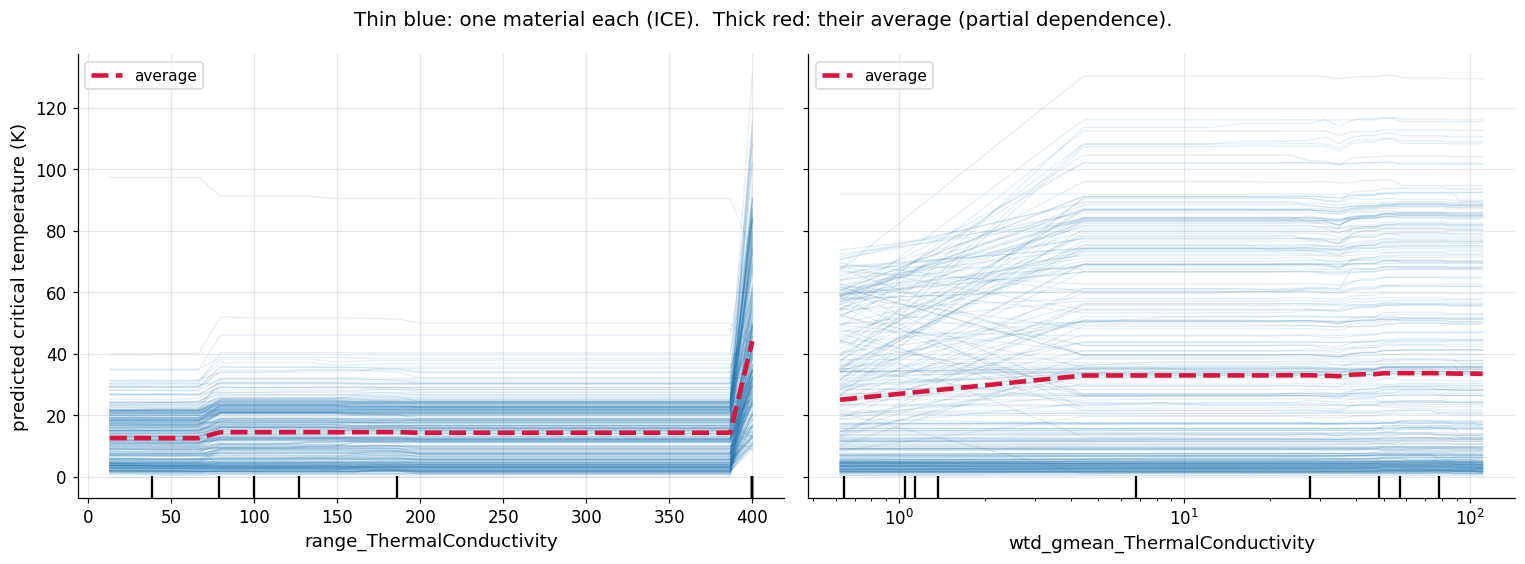

range_ThermalConductivity: the average prediction rises by 49.7 K across the plotted range
materials with range_ThermalConductivity = 399.97: 10419 of 21263
   their mean T_c: 59.9 K;   everyone else's: 9.9 K
   of the 3895 materials above 77 K, 3847 (99%) have it



wtd_gmean_ThermalConductivity, change in prediction across its range:
   average over the 300 materials:  +8.5 K
   middle 80% of them:              -1.1 K to +37.0 K
   average, 399.97 group / others:  +19.6 K / +0.1 K


In [ ]:
booster = HistGradientBoostingRegressor(max_iter=3000, learning_rate=0.05, max_leaf_nodes=127,
                                        random_state=0).fit(X_sc_train, y_sc_train)
examples = X_sc_train.sample(300, random_state=0)
features = ["range_ThermalConductivity", "wtd_gmean_ThermalConductivity"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
PartialDependenceDisplay.from_estimator(
    booster, examples, features, kind="both", grid_resolution=30, ax=axes, random_state=0,
    ice_lines_kw={"color": "tab:blue", "alpha": 0.12, "linewidth": 0.8},
    pd_line_kw={"color": "crimson", "linewidth": 3})
axes[0].set_ylabel("predicted critical temperature (K)")
axes[1].set_ylabel("")
axes[1].set_xscale("log")        # the feature is heavily skewed: most materials sit below 10
fig.suptitle("Thin blue: one material each (ICE).  Thick red: their average (partial dependence).",
             fontsize=13)
plt.show()

# How big is the jump in the red curve of the left panel?
average_curve = partial_dependence(booster, examples, [features[0]], kind="average",
                                   grid_resolution=30)["average"][0]
print(f"{features[0]}: the average prediction rises by {average_curve[-1] - average_curve[0]:.1f} K"
      f" across the plotted range")

# What is special about the top of the first feature?
copper_like = (X_sc["range_ThermalConductivity"] - 399.97).abs() < 0.01
hot = y_sc > 77
print(f"materials with range_ThermalConductivity = 399.97: {copper_like.sum()} of {len(y_sc)}")
print(f"   their mean T_c: {y_sc[copper_like].mean():.1f} K;   everyone else's: "
      f"{y_sc[~copper_like].mean():.1f} K")
print(f"   of the {hot.sum()} materials above 77 K, {(copper_like & hot).sum()} "
      f"({(copper_like & hot).sum() / hot.sum():.0%}) have it")

# How different are the ICE curves of the second feature, from one end to the other?
curves_ice = partial_dependence(booster, examples, [features[1]], kind="individual",
                                grid_resolution=30)["individual"][0]
change = curves_ice[:, -1] - curves_ice[:, 0]
in_group = copper_like.loc[examples.index].to_numpy()
print(f"\n{features[1]}, change in prediction across its range:")
print(f"   average over the 300 materials:  {change.mean():+.1f} K")
print(f"   middle 80% of them:              {np.percentile(change, 10):+.1f} K to "
      f"{np.percentile(change, 90):+.1f} K")
print(f"   average, 399.97 group / others:  {change[in_group].mean():+.1f} K / "
      f"{change[~in_group].mean():+.1f} K")

**The left panel is a jump.** For almost the whole range of `range_ThermalConductivity` the model's
prediction does not move; the average rises by about 50 K, almost all of it in one jump at the very
top. The printout says why the top is special. 10,419 of the 21,263 materials have *exactly* the
same value, 399.97, their mean $T_c$ is 59.9 K against 9.9 K for everyone else, and they include 99%
of the materials that superconduct above 77 K — the boiling point of liquid nitrogen, the line that
matters for applications.

A physicist will suspect what that value marks. The feature is the difference between the highest
and lowest thermal conductivity among a compound's elements, and copper's is about 400 W/(m·K) while
oxygen's is close to zero — so a value of almost exactly 400 marks compounds containing both copper
and oxygen: the **cuprates**, the family of high-temperature superconductors. The dataset's own
paper agrees. Hamidieh (2018) reports that cuprates make up about 49.5% of these materials, with a
mean $T_c$ of 59.9 K — the same mean as the 399.97 group above — and found
`range_ThermalConductivity` to be the most important feature of his own boosted model. The model
has, in effect, learned "is it a cuprate?" from a feature nobody designed for that purpose. Exercise
2 checks it formula by formula.

**The right panel is why ICE exists.** The red average says that `wtd_gmean_ThermalConductivity`
raises the prediction by 8.5 K across its range — a modest effect. The blue curves say something
else: for the middle 80% of materials the change runs from −1.1 K to +37.0 K. For most, the feature
does little; for some, it matters a great deal. And the split is not random: in the 399.97 group the
average change is +19.6 K, elsewhere +0.1 K. The feature's effect **depends on another feature** —
an **interaction** — and an average of the curves cannot show that. Fanning ICE curves are how you
see one.

> **Neither plot is causal.** Each shows what the *model* predicts when one input is changed and the
> others are held fixed — not what would happen to a real material. And holding the others fixed can
> produce combinations that never occur: these features are strongly correlated (`04B` §7.1), so
> sliding one while freezing the rest walks the model into regions it has never seen data from. The
> curves there are extrapolation. Accumulated local effects (Apley & Zhu, 2020) are a variant built
> to avoid this.

The most widely used tool of this kind is not in this notebook: **SHAP values** (Lundberg & Lee,
2017) split each individual prediction into a contribution from every feature, and have a fast exact
version for tree ensembles (Lundberg et al., 2020). They live in the `shap` package, and they
inherit the same caveats — a description of the model, sensitive to correlated features.

# 8. When boosted trees beat deep learning

The rest of this course is about neural networks, and it would be natural to assume that they are
simply better at everything. On tables like the ones in sections 5 and 7 — rows of samples, columns
of measured features — they are not clearly better, and often worse. The evidence is specific.

**Grinsztajn, Oyallon & Varoquaux (NeurIPS 2022)** compared tree ensembles with deep models on 45
tabular datasets of about 10,000 samples each, with comparable tuning budgets for every model. Tree-
based models — gradient boosting and random forests — remained the best, even before counting their
far lower training cost. They traced the gap to three properties of tabular data that neural
networks handle poorly:

1. **Uninformative features.** Real tables carry many columns that do not matter. Trees ignore a
   useless feature simply by never splitting on it; the networks' accuracy degraded as such columns
   were added.
2. **Irregular target functions.** A target can change sharply across a threshold — as $T_c$ does at
   the top of section 7's left panel. Trees represent a jump with one split; neural networks are
   biased towards smooth functions and approximate it poorly.
3. **Meaningful orientation.** In a table each column is a specific quantity, and trees split along
   the columns one at a time. Standard networks treat the inputs as if any rotation of them were
   equally natural, which throws that structure away.

**Shwartz-Ziv & Armon (2022)** reached a similar conclusion from a different direction: XGBoost beat
several deep models designed specifically for tables, including on the datasets their own papers had
used, and needed much less tuning. An ensemble of XGBoost *and* the deep models did best of all.

**Larger and more recent comparisons temper this.** McElfresh et al. (NeurIPS 2023), on 176
datasets, found that for a surprisingly large number of them the difference between boosted trees
and neural networks is negligible — lightly tuning the boosted model mattered more than the choice
between the two — while boosted trees were clearly better on tables with skewed or heavy-tailed
features. TabArena (Erickson et al., NeurIPS 2025), a benchmark that is continually updated, reports
that boosted trees remain strong contenders, but that deep models have caught up when given large
time budgets and ensembling.

**Where this stops being true.** Three limits are worth knowing.

- **When the inputs are not a table.** Images, spectra, sequences, molecular graphs: there the
  structure *is* the point, and neural networks built to exploit it — Classes 10 to 12 — win by a
  wide margin. A table of hand-made features computed from a formula, as in section 5, is exactly
  the setting where trees are strongest.
- **When there is a great deal of data.** The main benchmark deliberately studied medium-sized
  tables, of about 10,000 samples. How the comparison changes with far more data is less settled.
- **The picture is moving.** A pretrained transformer for tables, **TabPFN** (Hollmann et al.,
  Nature 2025), is reported to outperform tuned boosted trees on datasets of up to 10,000 samples.
  Whether that holds up across independent benchmarks is an active question.

The practical rule that follows is a good one: **for a table of measurements, fit a boosted model
first.** It is the baseline any neural network for that table has to beat, and often it is the
answer.

# 9. When boosting is the wrong tool

*This is the notebook's* **when this is the wrong tool** *section, as in `02A` §10, `04A` §11 and
`04B` §9.1.*

**You need predictions outside the range of the training data.** A boosted model is a sum of trees,
and every tree is constant beyond the last threshold it learned. The sum is constant there too.
`04A` §10 showed it for one tree, `04B` §9 for the forest, and boosting inherits it unchanged.

**The relationship is smooth, low-dimensional and has a known form.** A handful of variables and a
physical law with a few parameters — `02A`'s spring — is fitted better, and far more interpretably,
by the law itself. A sum of staircases can approximate a smooth curve, but it spends many trees
doing what one equation does exactly.

**The inputs are not a table.** Section 8's first limit: images, sequences and graphs belong to the
networks of later classes.

**You cannot afford to tune.** A forest with default settings is hard to get badly wrong (`04B`).
Boosting has more that matters — learning rate, tree size and rounds, which interact — and section 5
showed its defaults stopping at their round cap before they had finished improving. With too little
data to tune on, the forest is the safer choice; and section 7 showed a table on which it is simply
as good.

**You need one readable rule.** A boosted model is hundreds of trees, and each only makes sense as a
correction to the ones before it — less readable than a forest, where every tree is at least a
complete model. Section 7's plots describe it; they do not replace a single pruned tree from `04A`.

# 10. Common pitfalls

**Comparing a boosted model that hit its round limit.** Section 5: the defaults used all 100 rounds
they were allowed and were still improving when they were stopped. Always check `n_iter_` against
`max_iter` before comparing boosting with anything.

**Choosing the number of rounds on the test set.** Early stopping's validation set comes out of the
training data. Watching the test score while adding rounds is `02C` §5's error in another form.

**Turning the learning rate down and forgetting the rounds.** A learning rate ten times smaller
needed about seven times as many rounds in section 3. A small rate with the default 100 rounds is
simply an underfitted model.

**Reading a partial dependence plot as a causal effect.** It describes the model, not the material,
and with correlated features it averages over combinations that never occur (section 7).

**Trusting the average when the ICE curves fan out.** A flat or modest partial dependence can hide
large effects of opposite sign in different parts of the data. Draw the individual curves before
concluding that a feature does nothing.

**Assuming one method must be better.** Boosting beat the forest on one table and tied it on another
(sections 5 and 7), and section 8's evidence says the same of neural networks. Fit the boosted model
first, and make anything else beat it on your data.

# 11. Applying this to your own data

Everything above is about how boosting works. This section is about **using it**, and it is the same
seven-step cell as `03C` §8, `04A` §13 and `04B` §12 — deliberately, down to the numbering and the
map step each step carries out. Only step 4 changes when the method changes, and that invariance is
the transferable part: **the shape of a competent analysis does not depend on the model.**

What is particular to boosting:

- **Step 2 has no scaler**, for `04A` §11.1's reason: these are trees.
- **Step 4 tunes the learning rate and the tree size, and lets early stopping choose the rounds.**
  `max_iter` is set high so that it is never the thing that stops the fit (section 10's first
  pitfall), and `early_stopping=True` makes the validation step explicit rather than dependent on
  the dataset's size.
- **The metric is RMSE in kelvin**, because the question is how far a predicted $T_c$ is from the
  real one, in units a physicist can judge.

In [ ]:
from sklearn.dummy import DummyRegressor          # the "no model at all" of step 3
from sklearn.model_selection import GridSearchCV

# 1 (map step 2) — split first.  02C §6
X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y_sc, test_size=0.25, random_state=0)

# 2 (map step 5) — no pipeline and no scaler: boosted trees need neither.  04A §11.1
#     max_iter is only a ceiling; early stopping chooses the rounds inside every fit.
estimator = HistGradientBoostingRegressor(max_iter=3000, early_stopping=True, random_state=0)

# 3 (map step 6) — a baseline, so the final number has something to beat
baseline = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
baseline_rmse = np.sqrt(np.mean((y_te - baseline.predict(X_te)) ** 2))

# 4 (map step 8) — tune on the training set only.  THE ONLY BLOCK THAT CHANGES.
search = GridSearchCV(estimator,
                      {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [31, 63, 127]},
                      cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)

# 5 (map step 8) — the cross-validated score and the fold spread (not a standard error)
best = search.best_index_
cv_rmse = -search.cv_results_["mean_test_score"][best]
cv_spread = search.cv_results_["std_test_score"][best]

# 6 (map step 9) — the test set, once
residuals = np.asarray(y_te) - search.predict(X_te)
test_rmse = np.sqrt(np.mean(residuals ** 2))

# 7 (map step 9) — an error bar on it, by resampling the test set.  04B §2's bootstrap.
boot_rng = np.random.default_rng(0)
resampled = [np.sqrt(np.mean(residuals[boot_rng.integers(0, len(residuals), len(residuals))] ** 2))
             for _ in range(2000)]
low, high = np.percentile(resampled, [2.5, 97.5])

print(f"{len(y_tr)} training materials, {len(y_te)} test materials, {X_sc.shape[1]} features")
print(f"\nbaseline (predict the mean)         : RMSE {baseline_rmse:6.2f} K")
print(f"chosen learning rate / leaves       : {search.best_params_['learning_rate']}"
      f" / {search.best_params_['max_leaf_nodes']}"
      f"   ({search.best_estimator_.n_iter_} rounds, chosen by early stopping)")
print(f"cross-validated RMSE                : {cv_rmse:6.2f} K +/- {cv_spread:.2f} (fold spread)")
print(f"test RMSE                           : {test_rmse:6.2f} K   "
      f"95% bootstrap [{low:.2f}, {high:.2f}]")

print("\nthe whole grid, as cross-validation saw it:")
for params, score, spread in sorted(zip(search.cv_results_["params"],
                                        -search.cv_results_["mean_test_score"],
                                        search.cv_results_["std_test_score"]), key=lambda t: t[1]):
    print(f"   learning rate {params['learning_rate']:<5} leaves {params['max_leaf_nodes']:<4}"
          f" RMSE {score:5.2f} K +/- {spread:.2f}")

15947 training materials, 5316 test materials, 81 features

baseline (predict the mean)         : RMSE  34.18 K
chosen learning rate / leaves       : 0.1 / 31   (320 rounds, chosen by early stopping)
cross-validated RMSE                :   9.82 K +/- 0.30 (fold spread)
test RMSE                           :   9.72 K   95% bootstrap [9.30, 10.15]

the whole grid, as cross-validation saw it:
   learning rate 0.1   leaves 31   RMSE  9.82 K +/- 0.30
   learning rate 0.05  leaves 63   RMSE  9.84 K +/- 0.24
   learning rate 0.05  leaves 127  RMSE  9.85 K +/- 0.35
   learning rate 0.1   leaves 127  RMSE  9.85 K +/- 0.36
   learning rate 0.1   leaves 63   RMSE  9.87 K +/- 0.34
   learning rate 0.05  leaves 31   RMSE  9.98 K +/- 0.16


The chosen model uses a learning rate of 0.1 and trees of up to 31 leaves, and early stopping kept
320 rounds. Its cross-validated error, 9.82 K, and its test error, 9.72 K, agree — the difference,
0.10 K, is a third of the fold spread — and the bootstrap pins the test error down to about 0.4 K
either side, because 5,316 test materials is a lot of evidence.

**Look at the whole grid before believing the choice.** On section 7's shuffled folds, learning rate
0.05 with 127 leaves scored 9.69 K; on the folds used here it scores 9.85 K and loses. The six
settings span 9.82 K to 9.98 K — a range of 0.16 K, about half of one fold spread — so the search is
choosing between models it cannot really tell apart, and a different set of folds changes the
winner. That is `04B` §12's lesson again: report what was chosen and what it was worth, not the
hyperparameters as a finding.

### What to deliver — map step 10

- **Task and data** — predicting the critical temperature of 21,263 superconductors from 81 features
  computed from their chemical formulas (Hamidieh, 2018); 15,947 train, 5,316 test.
- **Protocol** — a single 75/25 split at `random_state=0`; no scaling, deliberately; the test set
  touched once.
- **Baseline** — predicting the training mean: RMSE 34.18 K.
- **Model and tuning** — histogram gradient boosting. Learning rate and maximum leaves per tree
  chosen by 5-fold cross-validation on the training materials; selected 0.1 and 31, from six
  settings that cross-validation could not really separate. The number of
  rounds chosen by early stopping inside each fit, on 10% of the training data: 320 for the final
  model.
- **Result** — cross-validated RMSE 9.82 K with a fold spread of 0.30 K; **test RMSE 9.72 K, 95%
  bootstrap interval [9.30, 10.15] K**.
- **Metric** — RMSE in kelvin, because the error is to be judged in the target's own units.
- **Limits** — the model cannot extrapolate beyond the $T_c$ range and compositions it was trained
  on, which matters for exactly the new materials one would most want to predict (section 9); its
  explanations describe the model, not the physics (section 7); and its features are summaries of a
  formula, so two materials with the same elements in the same proportions are indistinguishable to
  it.

**A project notebook is expected to contain a block like this.** It is what turns a fitted model
into a result.

# 12. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Boosting a classifier</b><br>
Section 2.1 claimed that classification changes only what the trees are fitted to.
<br><br>
1. Load the breast-cancer data of <code>04B</code> and fit <code>HistGradientBoostingClassifier</code> with its defaults.<br>
2. Cross-validate it against <code>04B</code>'s random forest of 300 trees, using ROC AUC as the metric.<br>
3. Check <code>n_iter_</code>. Was early stopping on? Why, given the size of this dataset?<br>
4. Is the difference between the two models larger than the fold spread? What would you report?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Is it really copper?</b><br>
Section 7 identified <code>range_ThermalConductivity = 399.97</code> with the copper oxides, from
the dataset paper's statistics. The chemical
formulas are published with the dataset on the UCI Machine Learning Repository, as
<code>unique_m.csv</code>, in the same row order as the features.
<br><br>
1. Download the file and read it with pandas.<br>
2. For the materials with that exact value, what fraction contain both Cu and O? What fraction of
the others do?<br>
3. Is there a material with the value 399.97 that contains no copper? What does it contain instead?<br>
4. What does a check formula by formula add to the statistical argument of section 7?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — A categorical feature, natively</b><br>
Add a coarse, categorical version of a real feature and see how the model handles it.
<br><br>
1. Create a column <code>size_class</code> by cutting <code>number_of_elements</code> into
"few" (1–2), "some" (3–4) and "many" (5 or more), and give it pandas' <code>category</code> type.<br>
2. Replace <code>number_of_elements</code> by <code>size_class</code> and cross-validate
<code>HistGradientBoostingRegressor</code>. Does it run without any encoding step?<br>
3. Try the same table with <code>Ridge</code>. What happens, and what would you have to add?<br>
4. Why might a tree-based model prefer the original numerical column to the categorical one?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **Boosting** builds a model one shallow tree at a time: each tree is fitted to the residuals of
  all the trees before it, and added in with a small weight, the **learning rate**. A written-out
  loop and `GradientBoostingRegressor` agree to rounding error.
- The residual is the **negative gradient** of squared error; for any other loss the trees are
  fitted to that loss's negative gradient — for classification, the label minus the predicted
  probability.
- A forest averages deep, independent trees and reduces **variance**; boosting adds shallow,
  sequential trees and reduces **bias**.
- The number of rounds is a **flexibility dial that overfits**: training error goes to zero while
  the error on fresh data passes a minimum and rises. A smaller learning rate needs many more
  rounds.
- **Early stopping** chooses the rounds on a validation set carved from the training data;
  `HistGradientBoostingRegressor` switches it on by itself above 10,000 samples.
- **Boosting versus forest depends on the table.** On California housing boosting won by about two
  and a half fold spreads, even with its defaults; on the superconductor data the two tied. Check
  `n_iter_` against `max_iter` before comparing anything.
- **Partial dependence** shows a feature's average effect in the model; **ICE** curves show it for
  each sample, and fanning curves reveal interactions the average hides. Neither is causal.
- On tables of measured features, boosted trees are the strong, cheap default and the baseline any
  neural network has to beat. Recent benchmarks find the gap often negligible and closing with large
  budgets; for images, sequences or graphs, networks win.

# Optional preparation for the next class

Before Class 5, students should be comfortable with:

- the idea of a loss whose gradient tells a model how to improve, from `02A` §2.4 and section 2.1;
- the difference between a model's flexibility and the amount of data supporting it;
- the fact that trees needed no feature scaling (`04A` §11.1), because the next class depends on
  scaling completely.

Class 5 leaves trees behind. `05A` starts from a different idea of similarity — **distance** between
samples — and builds nearest-neighbour classifiers and support vector machines on it. Distances mix
the units of every feature, so the scaling that trees could ignore becomes essential again.